In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('../data_jobs.csv')


# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [40]:
df_india = df[df['job_country'] == 'India'].copy()
df_india['job_posted_month_no'] = df_india['job_posted_date'].dt.month
df_india_explode = df_india.explode('job_skills')

In [41]:
df_india_pivot = df_india_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_india_pivot.loc['Total'] = df_india_pivot.sum()
df_india_pivot = df_india_pivot[df_india_pivot.loc['Total'].sort_values(ascending=False).index]
df_india_pivot = df_india_pivot.drop('Total')
df_india_pivot

job_skills,python,sql,aws,spark,azure,tableau,r,hadoop,java,scala,...,symfony,fastify,fedora,erlang,esquisse,nuxt.js,svelte,suse,sqlserver,shogun
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,3192,3231,1407,1429,1352,868,846,908,857,683,...,0,0,0,0,0,0,0,0,0,0
2,2247,2274,1024,1075,919,631,560,716,645,477,...,0,0,0,0,0,0,0,0,1,0
3,2398,2404,1083,1096,963,657,603,626,646,497,...,0,0,0,0,0,0,0,1,0,0
4,2272,2366,1074,1093,938,650,575,646,651,479,...,0,0,0,0,0,0,0,0,0,0
5,1971,1951,964,921,823,523,448,522,510,438,...,0,0,0,0,0,0,0,0,0,0
6,2601,2515,1200,1217,1059,671,682,665,678,568,...,0,0,0,1,1,0,0,0,0,0
7,2427,2459,1111,1044,1060,641,640,640,575,526,...,0,0,1,0,0,0,0,0,0,1
8,2410,2436,1135,1091,976,730,721,624,613,466,...,1,0,0,0,0,1,0,0,0,0
9,2324,2322,1033,912,976,654,595,565,553,510,...,1,2,0,0,0,0,0,0,0,0


In [42]:
Data_totals= df_india.groupby('job_posted_month_no').size()

In [43]:
df_india_percent = df_india_pivot.div(Data_totals/ 100, axis=0)

In [45]:
# Changing month number to name
df_india_percent = df_india_percent.reset_index()
df_india_percent['job_posted_month'] = df_india_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_india_percent = df_india_percent.set_index('job_posted_month')
df_india_percent = df_india_percent.drop(columns='job_posted_month_no')

In [46]:
df_india_percent

job_skills,python,sql,aws,spark,azure,tableau,r,hadoop,java,scala,...,symfony,fastify,fedora,erlang,esquisse,nuxt.js,svelte,suse,sqlserver,shogun
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,57.868020,58.575054,25.507614,25.906454,24.510515,15.736041,15.337201,16.461204,15.536621,12.382161,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Feb,56.958175,57.642586,25.956907,27.249683,23.295311,15.994930,14.195184,18.149556,16.349810,12.091255,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.025349,0.00000
Mar,59.562842,59.711873,26.900149,27.223050,23.919523,16.318927,14.977645,15.548932,16.045703,12.344759,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.024839,0.000000,0.00000
Apr,56.658354,59.002494,26.783042,27.256858,23.391521,16.209476,14.339152,16.109726,16.234414,11.945137,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
May,60.330579,59.718396,29.507193,28.191001,25.191307,16.008571,13.712886,15.977961,15.610652,13.406795,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
Jun,61.972838,59.923755,28.591851,28.996903,25.232309,15.987610,16.249702,15.844651,16.154396,13.533476,...,0.000000,0.000000,0.00000,0.023827,0.023827,0.000000,0.000000,0.000000,0.000000,0.00000
Jul,58.879185,59.655507,26.952935,25.327511,25.715672,15.550704,15.526443,15.526443,13.949539,12.760796,...,0.000000,0.000000,0.02426,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.02426
Aug,56.111758,56.717113,26.426077,25.401630,22.724098,16.996508,16.786962,14.528522,14.272410,10.849825,...,0.023283,0.000000,0.00000,0.000000,0.000000,0.023283,0.000000,0.000000,0.000000,0.00000
Sep,56.490034,56.441420,25.109383,22.168206,23.723870,15.896937,14.462810,13.733593,13.441906,12.396694,...,0.024307,0.048614,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


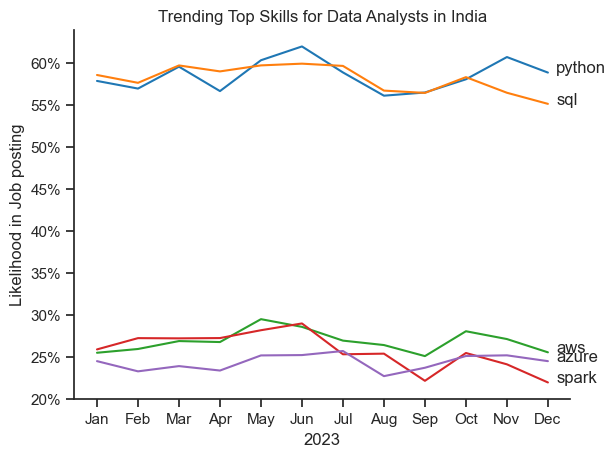

In [65]:
df_plot = df_india_percent.iloc[:,:5]
sns.lineplot(data = df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks') 
sns.despine()

plt.title('Trending Top Skills for Data Analysts in India')
plt.ylabel('Likelihood in Job posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax =plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1,i], df_plot.columns[i])